# Finding money laundering in a synthetic bank

This notebook works through a fraud analysis end to end on a bank that does not exist. Every customer, account and transaction in it was generated by GraphFaker, which means we also have something no real bank gives you: a written record of exactly which accounts and which transactions were part of a laundering scheme.

That record is what makes this worth doing. On real data you build a detector, ship it, and wait months to find out how it did. Here you can measure it in seconds, and more importantly you can measure the things that are usually invisible, like how many of your alerts were on perfectly innocent customers who happened to look suspicious.

**The dataset.** 71,429 customers holding 100,000 accounts, with 901,459 legitimate transactions over 90 days of 2024, plus 376 transactions belonging to 33 injected patterns. Generated with `--scale 0.01 --seed 42 --hardness medium`, so it is reproducible: the same command gives anyone the same bank.

**How this notebook is organised.** We look at the data first and form opinions about it. Then we try the obvious rules and score them. Then we try graph algorithms. Then we build a model. Then we compare all three honestly and say what a bank should actually do about it.

**A note for anyone reading this who is not an analyst.** Every section ends with a plain summary of what it means for the business. You can read only those and get the argument.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from graphfaker.sinks import Target

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

# Two databases, same graph. `fraud` has the answers loaded as a subgraph;
# `fraud-blind` is the identical graph with none of them. Features come from
# the blind one so nothing can leak; labels come from the other.
TRUTH, BLIND = "fraud", "fraud-blind"
driver = Target().connect()

def native(value):
    """Neo4j hands back its own Date/DateTime classes, which polars treats as
    opaque objects. Convert them so the columns are real temporal types."""
    return value.to_native() if hasattr(value, "to_native") else value

def query(database, cypher, **params):
    """Run Cypher, get a polars DataFrame."""
    records, _, _ = driver.execute_query(cypher, database_=database, **params)
    rows = [{k: native(v) for k, v in r.data().items()} for r in records]
    return pl.DataFrame(rows, infer_schema_length=None) if rows else pl.DataFrame()

totals = query(TRUTH, "MATCH (n) RETURN count(n) AS nodes")
print(f"connected to {TRUTH}: {totals['nodes'][0]:,} nodes")

connected to fraud: 255,813 nodes


## 1. What is in the graph

Five kinds of thing, and money moving between them on three separate rails.

In [2]:
nodes = query(TRUTH, """
MATCH (n) UNWIND labels(n) AS label
RETURN label, count(*) AS count ORDER BY count DESC
""")
rels = query(TRUTH, """
MATCH ()-[r]->() RETURN type(r) AS relationship, count(*) AS count ORDER BY count DESC
""")
print(nodes)
print(rels)

shape: (7, 2)
┌──────────────┬────────┐
│ label        ┆ count  │
│ ---          ┆ ---    │
│ str          ┆ i64    │
╞══════════════╪════════╡
│ Account      ┆ 100000 │
│ Device       ┆ 82143  │
│ Customer     ┆ 71429  │
│ Merchant     ┆ 2000   │
│ Counterparty ┆ 200    │
│ Pattern      ┆ 33     │
│ Region       ┆ 8      │
└──────────────┴────────┘
shape: (6, 2)
┌──────────────┬────────┐
│ relationship ┆ count  │
│ ---          ┆ ---    │
│ str          ┆ i64    │
╞══════════════╪════════╡
│ PAYS         ┆ 619689 │
│ TRANSFERS    ┆ 247336 │
│ OWNS         ┆ 100000 │
│ USES         ┆ 87093  │
│ WIRES        ┆ 34434  │
│ IN_PATTERN   ┆ 205    │
└──────────────┴────────┘


The node labels and what they represent:

| label | count | what it is |
|---|---|---|
| `Customer` | 71,429 | a person, with a name, date of birth, contact details, a segment (retail, affluent, business) and a KYC tier |
| `Account` | 100,000 | a bank account, with a type, a status, a balance and an opening date. Roughly 1.4 accounts per customer |
| `Merchant` | 2,000 | a shop the bank's customers pay, in one of eleven categories |
| `Device` | 82,143 | a phone, laptop or tablet a customer logs in from |
| `Counterparty` | 200 | an account at another bank, in another country, that money can be wired to |
| `Pattern` | 33 | not part of the bank. This is the ground truth, covered in section 2 |
| `Region` | 8 | also ground truth: the eight latent regions the generator drew incomes and balances from |

The relationships matter more than the nodes, because this is where the behaviour lives:

- **`OWNS`** (100,000) joins a customer to their accounts.
- **`USES`** (87,093) joins a customer to their devices. Most customers have one or two. About 6% of devices are shared by two customers in the same region, which the generator calls households. That detail matters later: shared devices are a fraud signal, and there has to be innocent sharing for the signal to be worth anything.
- **`PAYS`** (619,689) is an account paying a merchant. This is ordinary spending and it is the bulk of the data.
- **`TRANSFERS`** (247,336) is an account paying another account inside the bank. This is where laundering happens, because it is the only rail where money can move around a ring.
- **`WIRES`** (34,434) is an account sending money to a counterparty abroad. This is how money leaves.

Every transaction carries a `tx_id`, a `timestamp`, an `amount`, a `memo` and a `recurring` flag.

In [3]:
rails = query(TRUTH, """
MATCH ()-[r:PAYS|TRANSFERS|WIRES]->()
RETURN type(r) AS rail, count(*) AS transactions, round(sum(r.amount)) AS total_value,
       round(avg(r.amount)) AS mean, round(percentileCont(r.amount, 0.5)) AS median,
       round(max(r.amount)) AS largest
ORDER BY transactions DESC
""")
print(rails)

shape: (3, 6)
┌───────────┬──────────────┬──────────────┬────────┬────────┬──────────┐
│ rail      ┆ transactions ┆ total_value  ┆ mean   ┆ median ┆ largest  │
│ ---       ┆ ---          ┆ ---          ┆ ---    ┆ ---    ┆ ---      │
│ str       ┆ i64          ┆ f64          ┆ f64    ┆ f64    ┆ f64      │
╞═══════════╪══════════════╪══════════════╪════════╪════════╪══════════╡
│ PAYS      ┆ 619689       ┆ 1.59030141e8 ┆ 257.0  ┆ 54.0   ┆ 12692.0  │
│ TRANSFERS ┆ 247336       ┆ 3.37066756e8 ┆ 1363.0 ┆ 162.0  ┆ 123510.0 │
│ WIRES     ┆ 34434        ┆ 5.9653378e7  ┆ 1732.0 ┆ 1105.0 ┆ 59030.0  │
└───────────┴──────────────┴──────────────┴────────┴────────┴──────────┘


The three rails behave differently, which is the first thing worth noticing. `PAYS` is high volume and low value, the shape of retail spending. `WIRES` is low volume and higher value. `TRANSFERS` sits in between.

A useful sanity check on any transaction dataset is whether the amounts are log-normal, because real money almost always is. Most payments are small, a few are very large, and the distribution is straight when you plot it on a log scale.

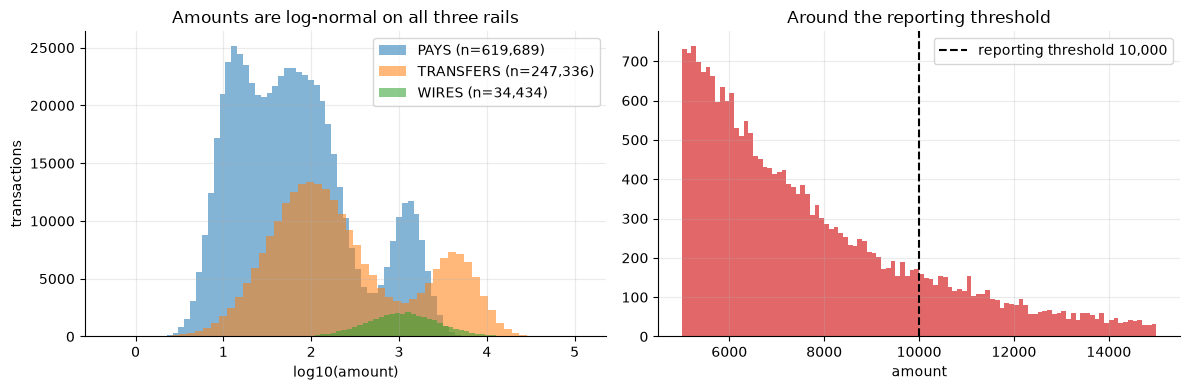

In [4]:
amounts = query(TRUTH, """
MATCH ()-[r:PAYS|TRANSFERS|WIRES]->()
RETURN type(r) AS rail, r.amount AS amount
""")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for rail in ["PAYS", "TRANSFERS", "WIRES"]:
    v = amounts.filter(pl.col("rail") == rail)["amount"].to_numpy()
    axes[0].hist(np.log10(v[v > 0]), bins=60, alpha=0.55, label=f"{rail} (n={len(v):,})")
axes[0].set_xlabel("log10(amount)"); axes[0].set_ylabel("transactions")
axes[0].set_title("Amounts are log-normal on all three rails"); axes[0].legend()

# The cash reporting threshold is 10,000. Structuring hides just underneath it.
v = amounts.filter(pl.col("amount").is_between(5000, 15000))["amount"].to_numpy()
axes[1].hist(v, bins=100, color="tab:red", alpha=0.7)
axes[1].axvline(10000, color="black", ls="--", label="reporting threshold 10,000")
axes[1].set_xlabel("amount"); axes[1].set_title("Around the reporting threshold"); axes[1].legend()
plt.tight_layout(); plt.show()

The right-hand chart is the one an AML analyst goes looking for. Banks must report cash movements over a threshold, 10,000 here, so launderers break a large sum into pieces that each sit just below it. That practice is called structuring, and when it is present in volume you see a cliff at the threshold: lots of transactions at 9,900 and very few at 10,100.

There is no dramatic cliff in this data. That is not a flaw, it is scale. Only a handful of the 33 injected patterns are structuring, so their transactions are a rounding error against 900,000 legitimate ones. Which is exactly the real problem: the signal is there, it is just nowhere near the top of the chart.

Now the time dimension. 90 days from 1 January 2024.

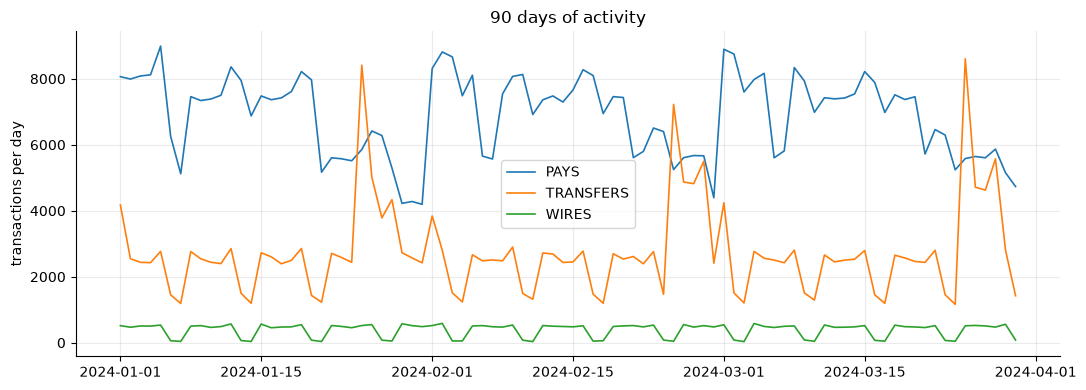

shape: (7, 2)
┌─────┬────────┐
│ dow ┆ n      │
│ --- ┆ ---    │
│ i64 ┆ i64    │
╞═════╪════════╡
│ 1   ┆ 89864  │
│ 2   ┆ 87362  │
│ 3   ┆ 82819  │
│ 4   ┆ 87733  │
│ 5   ┆ 100720 │
│ 6   ┆ 95337  │
│ 7   ┆ 75854  │
└─────┴────────┘


In [5]:
daily = query(TRUTH, """
MATCH ()-[r:PAYS|TRANSFERS|WIRES]->()
RETURN date(r.timestamp) AS day, type(r) AS rail, count(*) AS n
""").sort("day")

fig, ax = plt.subplots(figsize=(11, 4))
for rail in ["PAYS", "TRANSFERS", "WIRES"]:
    s = daily.filter(pl.col("rail") == rail).sort("day")
    ax.plot(s["day"].to_list(), s["n"].to_list(), label=rail, lw=1.2)
ax.set_ylabel("transactions per day"); ax.set_title("90 days of activity")
ax.legend(); plt.tight_layout(); plt.show()

weekday = query(TRUTH, """
MATCH ()-[r:PAYS]->()
RETURN r.timestamp.dayOfWeek AS dow, count(*) AS n ORDER BY dow
""")
print(weekday)

**What this means for the business.** The bank looks like a bank. Spending dominates, money leaves through a small number of foreign counterparties, amounts follow the distribution real money follows, and activity has a weekly rhythm. Anything we find later is being found against a realistic background, not an obviously synthetic one.

## 2. What "truth" means here

This is the part with no real-world equivalent, so it is worth being precise about it.

When GraphFaker generates the bank it does two separate jobs. First it simulates ordinary banking: it draws customers, gives them accounts and devices, and runs a transaction process with recurring payments, favourite merchants, popular shops, seasonality and income effects. Then it goes back and **injects** laundering patterns into that history, writing down as it goes exactly what it put in and where.

That written record is the `truth/` folder in the dataset, and we loaded it into Neo4j as its own small subgraph:

- **`(:Pattern)`** is one injected scheme. It records the `typology` (the shape of the scheme), how many accounts and transactions it used, when it started and ended, and crucially an `is_fraud` flag.
- **`(:Account)-[:IN_PATTERN {role}]->(:Pattern)`** says an account took part, and what it did. `role` is `source`, `collector`, `mule` and so on.
- Labelled transactions carry `is_fraud`, `pattern_id` and `typology` on the relationship itself.

Membership is a relationship rather than a column on the account for a concrete reason: an account can be in more than one scheme. In this dataset there are 205 memberships spread across 181 distinct accounts, so putting a single `typology` on each account would quietly throw rows away.

In [6]:
patterns = query(TRUTH, """
MATCH (p:Pattern)
RETURN p.typology AS typology, p.is_fraud AS is_fraud, count(*) AS patterns,
       sum(p.n_accounts) AS accounts, sum(p.n_transactions) AS transactions
ORDER BY typology, is_fraud DESC
""")
print(patterns)

totals = query(TRUTH, """
CALL () { MATCH (p:Pattern) WHERE p.is_fraud RETURN count(*) AS fraud_patterns }
CALL () { MATCH (p:Pattern) WHERE NOT p.is_fraud RETURN count(*) AS decoy_patterns }
CALL () { MATCH (a:Account)-[:IN_PATTERN]->(p:Pattern) WHERE p.is_fraud
          RETURN count(DISTINCT a) AS fraud_accounts }
CALL () { MATCH (a:Account)-[:IN_PATTERN]->(p:Pattern) WHERE NOT p.is_fraud
          RETURN count(DISTINCT a) AS decoy_accounts }
CALL () { MATCH ()-[r:TRANSFERS|PAYS|WIRES]->() WHERE r.is_fraud
          RETURN count(r) AS fraud_transactions }
RETURN fraud_patterns, decoy_patterns, fraud_accounts, decoy_accounts, fraud_transactions
""")
print(totals)

shape: (14, 5)
┌────────────────────┬──────────┬──────────┬──────────┬──────────────┐
│ typology           ┆ is_fraud ┆ patterns ┆ accounts ┆ transactions │
│ ---                ┆ ---      ┆ ---      ┆ ---      ┆ ---          │
│ str                ┆ bool     ┆ i64      ┆ i64      ┆ i64          │
╞════════════════════╪══════════╪══════════╪══════════╪══════════════╡
│ bipartite          ┆ true     ┆ 2        ┆ 12       ┆ 14           │
│ bust_out           ┆ true     ┆ 2        ┆ 2        ┆ 31           │
│ cycle              ┆ true     ┆ 2        ┆ 9        ┆ 9            │
│ cycle              ┆ false    ┆ 3        ┆ 12       ┆ 12           │
│ fan_in             ┆ true     ┆ 2        ┆ 18       ┆ 16           │
│ …                  ┆ …        ┆ …        ┆ …        ┆ …            │
│ mule_network       ┆ true     ┆ 2        ┆ 16       ┆ 43           │
│ scatter_gather     ┆ true     ┆ 2        ┆ 19       ┆ 30           │
│ stack              ┆ true     ┆ 2        ┆ 7        ┆ 5     

So the scoreboard is: **22 fraud patterns using 121 accounts and 376 transactions, against 100,000 accounts and 901,459 legitimate transactions.** The fraud is 0.12% of accounts and 0.04% of transactions. Every detection number later in this notebook has to be read against that base rate.

### Decoys, and why they are the most useful thing in the dataset

Look at the `is_fraud = false` rows in the table above. There are 11 more patterns, using 60 accounts, that are shaped exactly like laundering and are completely legitimate. Three legitimate cycles, four legitimate fan-ins, four legitimate fan-outs.

These are the decoys, and they are the reason this dataset is worth using. Money genuinely does move in circles between honest people: you pay a friend, they pay a shared landlord, the landlord pays you back for something. Money genuinely does fan in: a group chips in for a holiday. If you build a detector that finds cycles, it will find these, and in the real world every one of them is a customer you just accused of money laundering.

Without decoys you can measure recall (did I find the fraud?) but you cannot honestly measure precision, because your false positives are all random accounts that are easy to dismiss. Decoys give you *hard* false positives. Watch what they do to the rules in section 3.

### The eleven typologies, in plain language

| typology | what it is |
|---|---|
| `fan_in` | many accounts send to one collector |
| `fan_out` | one account sprays money to many |
| `cycle` | money moves around a ring and returns to where it started |
| `scatter_gather` | split across many accounts, then recombined |
| `gather_scatter` | collected from many, then dispersed |
| `mule_network` | a chain of intermediaries passing money along |
| `structuring` | one sum broken into pieces that each stay under the reporting threshold |
| `stack` | layered transfers through several accounts to lengthen the trail |
| `bust_out` | an account behaves normally, builds trust, then drains |
| `bipartite` | two groups of accounts trading across each other |
| `synthetic_identity` | fabricated customers, often sharing devices |

### The blind copy

We loaded the same graph twice. `fraud` has the truth subgraph. `fraud-blind` is byte for byte the same bank with none of it: no `Pattern` nodes, no `is_fraud` anywhere. Everything we build from here on reads features from `fraud-blind`, and touches `fraud` only to score. It is the same discipline as a held-out test set, and it is worth the small extra effort because the alternative is a model that looks brilliant and is reading the answer.

In [7]:
print("labels visible in each database:")
for db in (TRUTH, BLIND):
    row = query(db, """
    CALL () { MATCH (n) WHERE n:Pattern OR n:Region RETURN count(n) AS truth_nodes }
    CALL () { MATCH ()-[r]->() WHERE r.is_fraud IS NOT NULL RETURN count(r) AS labelled_rels }
    RETURN truth_nodes, labelled_rels
    """)
    print(f"  {db:12} truth nodes {row['truth_nodes'][0]:>4}   labelled relationships {row['labelled_rels'][0]:>4}")

labels visible in each database:


  fraud        truth nodes   41   labelled relationships  581


Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `Pattern` does not exist in database `fraud-blind`. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=33, offset=33>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 33, 'line': 2, 'column': 33}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    CALL () { MATCH (n) WHERE n:Pattern OR n:Region RETURN count(n) AS truth_nodes }\n    CALL () { MATCH ()-[r]->() WHERE r.is_fraud IS NOT NULL RETURN count(r) AS labelled_rels }\n    RETURN truth_nodes, labelled_rels\n    '


Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `Region` does not exist in database `fraud-blind`. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=46, offset=46>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 46, 'line': 2, 'column': 46}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    CALL () { MATCH (n) WHERE n:Pattern OR n:Region RETURN count(n) AS truth_nodes }\n    CALL () { MATCH ()-[r]->() WHERE r.is_fraud IS NOT NULL RETURN count(r) AS labelled_rels }\n    RETURN truth_nodes, labelled_rels\n    '


Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `is_fraud` does not exist in database `fraud-blind`. Verify that the spelling is correct.', position=<SummaryInputPosition line=3, column=40, offset=125>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 125, 'line': 3, 'column': 40}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    CALL () { MATCH (n) WHERE n:Pattern OR n:Region RETURN count(n) AS truth_nodes }\n    CALL () { MATCH ()-[r]->() WHERE r.is_fraud IS NOT NULL RETURN count(r) AS labelled_rels }\n    RETURN truth_nodes, labelled_rels\n    '


  fraud-blind  truth nodes    0   labelled relationships    0


**What this means for the business.** We know the answer in advance, which lets us put a number on how good any detection approach is before it ever touches a customer. And because the dataset includes legitimate customers who look guilty, the false-positive numbers we produce are realistic rather than flattering.

## 3. Does the fraud look any different?

Before writing a single rule, the honest question is whether these 121 accounts are distinguishable at all. Let us compare them against everyone else on the features an analyst would reach for first.

In [8]:
profile = query(TRUTH, """
MATCH (a:Account)
OPTIONAL MATCH (a)-[:IN_PATTERN]->(p:Pattern)
WITH a, CASE WHEN p IS NULL THEN 'ordinary'
             WHEN p.is_fraud THEN 'fraud' ELSE 'decoy' END AS group
OPTIONAL MATCH (a)<-[i:TRANSFERS]-(:Account)
WITH a, group, count(i) AS in_n, coalesce(sum(i.amount), 0.0) AS in_sum,
     count(DISTINCT startNode(i)) AS senders
OPTIONAL MATCH (a)-[o:TRANSFERS]->(:Account)
RETURN group, a.id AS account, in_n, in_sum, senders,
       count(o) AS out_n, coalesce(sum(o.amount), 0.0) AS out_sum, a.balance AS balance
""")

summary = (profile.group_by("group")
    .agg([pl.len().alias("accounts"),
          pl.col("in_n").mean().round(2).alias("transfers_in"),
          pl.col("senders").mean().round(2).alias("distinct_senders"),
          pl.col("in_sum").mean().round(0).alias("value_in"),
          pl.col("out_n").mean().round(2).alias("transfers_out"),
          pl.col("out_sum").mean().round(0).alias("value_out")])
    .sort("accounts"))
print(summary)

shape: (3, 7)
┌──────────┬──────────┬──────────────┬──────────────────┬──────────┬───────────────┬───────────┐
│ group    ┆ accounts ┆ transfers_in ┆ distinct_senders ┆ value_in ┆ transfers_out ┆ value_out │
│ ---      ┆ ---      ┆ ---          ┆ ---              ┆ ---      ┆ ---           ┆ ---       │
│ str      ┆ u32      ┆ f64          ┆ f64              ┆ f64      ┆ f64           ┆ f64       │
╞══════════╪══════════╪══════════════╪══════════════════╪══════════╪═══════════════╪═══════════╡
│ decoy    ┆ 60       ┆ 5.02         ┆ 4.33             ┆ 6531.0   ┆ 6.48          ┆ 15927.0   │
│ fraud    ┆ 121      ┆ 4.72         ┆ 2.6              ┆ 13835.0  ┆ 3.64          ┆ 9403.0    │
│ ordinary ┆ 99819    ┆ 2.47         ┆ 1.61             ┆ 3361.0   ┆ 2.47          ┆ 3356.0    │
└──────────┴──────────┴──────────────┴──────────────────┴──────────┴───────────────┴───────────┘


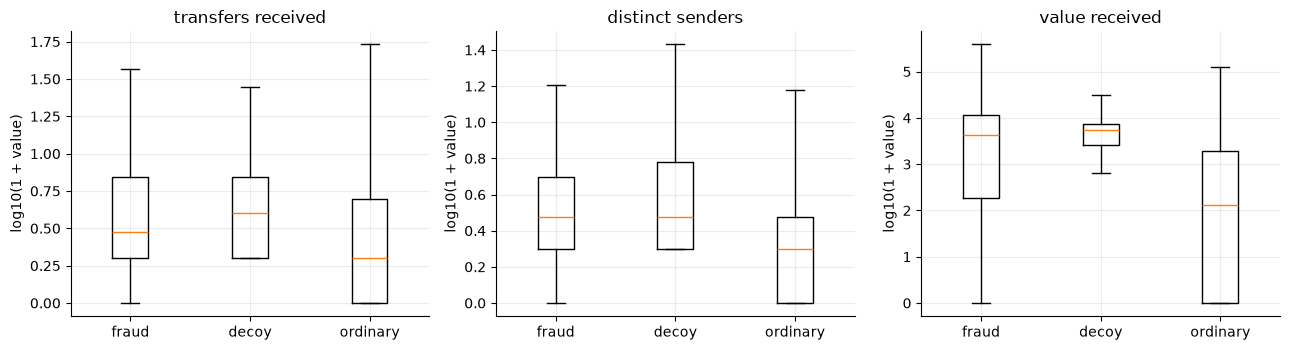

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, title in zip(axes, ["in_n", "senders", "in_sum"],
                          ["transfers received", "distinct senders", "value received"]):
    data, labels = [], []
    for g in ["fraud", "decoy", "ordinary"]:
        v = profile.filter(pl.col("group") == g)[col].to_numpy().astype(float)
        data.append(np.log10(v + 1)); labels.append(g)
    ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.set_title(title); ax.set_ylabel("log10(1 + value)")
plt.tight_layout(); plt.show()

Read that table carefully, because it does not say what you would expect, and the surprise shapes everything that follows.

Fraud accounts receive about the same number of transfers as decoy accounts, 4.7 against 5.0, and roughly twice as many as an ordinary account. Fine. But look at the sender column. **Fraud accounts receive from fewer distinct senders than decoys do**, 2.6 against 4.3. And look at the value column: fraud accounts take in about 13,800 against the decoys' 6,500 and an ordinary account's 3,400.

So the two groups differ in opposite directions on the two features an analyst reaches for first. Money launderers here move more money through fewer relationships. The legitimate lookalikes, the group holiday funds and shared household pots, involve more people moving less money.

That has a direct and slightly uncomfortable consequence. **Counting distinct senders, the single most popular fan-in signal in AML, points more strongly at the innocent group than at the guilty one.** Section 4 walks straight into that trap on purpose, because it is worth seeing happen.

The other caution is arithmetic. These are averages over groups of 121, 60 and 99,819. The distributions overlap heavily, and there are far more ordinary accounts in the tail of "busy" than there are fraud accounts in total. Any threshold on any of these features pulls in vastly more innocent accounts than guilty ones, simply because there are 800 times more of them.

**What this means for the business.** The fraud is not invisible. It is also not separable by any single number, and the most intuitive number available is actively misleading. Expect to need value and concentration signals, not just counts, and expect false positives to be dominated by ordinary customers who are simply busy.

## 4. First attempt: rules

This is where most AML programmes live, and for good reason: rules are explainable, auditable and a regulator can read them. Let us write the obvious ones and score them properly.

Every rule below produces a set of account ids from the **blind** database. Then we score it against truth. The two numbers that matter:

- **Precision** is the share of our alerts that were real fraud. Low precision means we waste investigator time and annoy customers.
- **Recall** is the share of the real fraud we found. Low recall means we missed crime.

You cannot maximise both. The whole job is choosing where to sit.

In [10]:
RULES = {
 "fan-in >= 8 senders, whole period": """
MATCH (dst:Account)<-[:TRANSFERS]-(src:Account)
WITH dst, count(DISTINCT src) AS senders WHERE senders >= 8
RETURN DISTINCT dst.id AS id""",

 "fan-in >= 5 senders in one week": """
MATCH (dst:Account)<-[t:TRANSFERS]-(src:Account)
WITH dst, t.timestamp.week AS week, count(DISTINCT src) AS senders WHERE senders >= 5
RETURN DISTINCT dst.id AS id""",

 "...and the burst is >80% of lifetime inflow": """
MATCH (dst:Account)<-[t:TRANSFERS]-(:Account)
WITH dst, sum(t.amount) AS lifetime
MATCH (dst)<-[t:TRANSFERS]-(src:Account)
WITH dst, lifetime, t.timestamp.week AS week,
     count(DISTINCT src) AS senders, sum(t.amount) AS burst
WHERE senders >= 5 AND burst > 0.8 * lifetime
RETURN DISTINCT dst.id AS id""",

 "three-hop cycle": """
MATCH (a:Account)-[t1:TRANSFERS]->(b:Account)-[t2:TRANSFERS]->(c:Account)-[t3:TRANSFERS]->(a)
WHERE t1.timestamp < t2.timestamp AND t2.timestamp < t3.timestamp
  AND duration.inDays(t1.timestamp, t3.timestamp).days <= 30
UNWIND [a.id, b.id, c.id] AS id RETURN DISTINCT id""",

 "amounts just under the threshold": """
MATCH (a:Account)-[t:TRANSFERS|WIRES]->()
WHERE t.amount > 8500 AND t.amount < 10000
WITH a, count(t) AS n WHERE n >= 3 RETURN DISTINCT a.id AS id""",

 "24-hour pass-through": """
MATCH (:Account)-[i:TRANSFERS]->(mid:Account)-[o:TRANSFERS]->(:Account)
WHERE o.timestamp > i.timestamp
  AND duration.inSeconds(i.timestamp, o.timestamp).seconds < 86400
  AND abs(o.amount - i.amount) / i.amount < 0.1
RETURN DISTINCT mid.id AS id""",
}

# The answers, fetched once.
fraud_accounts = set(query(TRUTH, """
MATCH (a:Account)-[:IN_PATTERN]->(p:Pattern) WHERE p.is_fraud RETURN DISTINCT a.id AS id
""")["id"].to_list())
decoy_accounts = set(query(TRUTH, """
MATCH (a:Account)-[:IN_PATTERN]->(p:Pattern) WHERE NOT p.is_fraud RETURN DISTINCT a.id AS id
""")["id"].to_list())

def score(flagged, name):
    flagged = set(flagged)
    tp = flagged & fraud_accounts
    return {"rule": name, "alerts": len(flagged), "caught": len(tp),
            "precision_pct": round(100 * len(tp) / len(flagged), 1) if flagged else 0.0,
            "recall_pct": round(100 * len(tp) / len(fraud_accounts), 1),
            "decoys_hit": len(flagged & decoy_accounts)}

rule_hits = {name: set(query(BLIND, c)["id"].to_list()) for name, c in RULES.items()}
scored = pl.DataFrame([score(ids, name) for name, ids in rule_hits.items()])
print(scored)

shape: (6, 6)
┌─────────────────────────────────┬────────┬────────┬───────────────┬────────────┬────────────┐
│ rule                            ┆ alerts ┆ caught ┆ precision_pct ┆ recall_pct ┆ decoys_hit │
│ ---                             ┆ ---    ┆ ---    ┆ ---           ┆ ---        ┆ ---        │
│ str                             ┆ i64    ┆ i64    ┆ f64           ┆ f64        ┆ i64        │
╞═════════════════════════════════╪════════╪════════╪═══════════════╪════════════╪════════════╡
│ fan-in >= 8 senders, whole per… ┆ 2473   ┆ 8      ┆ 0.3           ┆ 6.6        ┆ 9          │
│ fan-in >= 5 senders in one wee… ┆ 192    ┆ 7      ┆ 3.6           ┆ 5.8        ┆ 4          │
│ ...and the burst is >80% of li… ┆ 6      ┆ 4      ┆ 66.7          ┆ 3.3        ┆ 0          │
│ three-hop cycle                 ┆ 51     ┆ 0      ┆ 0.0           ┆ 0.0        ┆ 3          │
│ amounts just under the thresho… ┆ 643    ┆ 3      ┆ 0.5           ┆ 2.5        ┆ 1          │
│ 24-hour pass-through    

Read that table slowly, because almost every row is a lesson.

**The obvious rule is the worst one.** "Received from 8 or more different accounts" raises 2,473 alerts to find 8 frauds. That is 0.3% precision: 99.7% of the work is wasted. The reason is visible if you look at what it flagged: accounts receiving from 40 or 50 different senders spread evenly across all 90 days, totalling a few thousand pounds. Those are popular accounts, not collectors. Counting relationships with no time window measures popularity.

**Adding time helps a lot.** Requiring 5 senders inside a single week cuts alerts from 2,473 to 192 while keeping almost the same recall. Precision goes up more than tenfold for free.

**Adding behaviour helps enormously.** Also requiring that the burst be more than 80% of everything the account ever received takes it to 6 alerts and 4 frauds: 66.7% precision. A real collector's money arrives in a rush and that rush is most of its life. A popular account's inflow is spread out. That single extra condition is the difference between a rule you could deploy and one you could not.

**The cycle rule finds nothing.** Zero of the 51 accounts it flags are fraud. The reason is structural: the laundering cycles in this dataset are four and five hops long, and a three-hop query cannot see them at any threshold. Worth remembering whenever a query returns a tidy, plausible, wrong answer.

**And now the decoy column.** This is the one that should change how you read the whole table.

In [11]:
print("decoy accounts exist:", len(decoy_accounts))
print("\nhow much of each rule's alert volume is lookalike-legitimate customers:")
for name, ids in rule_hits.items():
    hit = ids & decoy_accounts
    if hit:
        share = 100 * len(hit) / len(decoy_accounts)
        print(f"  {name:<44} {len(hit):>2}/{len(decoy_accounts)} decoys ({share:.0f}% of them)")
    else:
        print(f"  {name:<44}  0 decoys")

decoy accounts exist: 60

how much of each rule's alert volume is lookalike-legitimate customers:
  fan-in >= 8 senders, whole period             9/60 decoys (15% of them)
  fan-in >= 5 senders in one week               4/60 decoys (7% of them)
  ...and the burst is >80% of lifetime inflow   0 decoys
  three-hop cycle                               3/60 decoys (5% of them)
  amounts just under the threshold              1/60 decoys (2% of them)
  24-hour pass-through                          0 decoys


The plain fan-in rule hits 9 of the 60 decoy accounts, and the weekly version hits 4, which is every decoy fan-in account in the dataset. Every legitimate group-payment situation, flagged. The three-hop cycle rule hits three decoy cycle accounts and no fraud at all, so it is purely a false-positive generator.

And the best rule, the one with the extra behavioural condition, hits **zero** decoys.

This is section 3 playing out exactly as the profile table predicted. Decoys have more senders than the fraud does, so any rule built on counting senders finds the decoys first. The rule that escaped the trap did so by asking about concentration of value instead of breadth of contact.

That is the finding worth taking away from this section. Rules that ask about *shape* catch every innocent customer who happens to be shaped that way. The rule that asked about *behaviour*, whether the money arrived in one concentrated burst, separated the guilty from the innocent lookalikes cleanly. Shape tells you where to look. It does not tell you what you have found.

**What this means for the business.** Simple rules are cheap and explainable, and one of them here is genuinely good, but only after two rounds of refinement that were guided by measurement. Without decoys in the test data, the weekly fan-in rule would have looked fine, and it would have gone live accusing group-holiday organisers of laundering.

## 5. Second attempt: graph algorithms

The reason to put this data in a graph database at all is to ask connectivity questions. Neo4j's Graph Data Science library gives us the standard toolkit, so let us try it and be honest about the result.

We project the transfer network into memory once, then run algorithms over it.

In [12]:
has_gds = bool(query(BLIND, "SHOW PROCEDURES YIELD name WHERE name = 'gds.version' RETURN count(*) AS n")["n"][0])
print("GDS available:", has_gds)

if has_gds:
    try:
        query(BLIND, "CALL gds.graph.drop('transfers', false) YIELD graphName RETURN graphName")
    except Exception:
        pass
    print(query(BLIND, """
    CALL gds.graph.project('transfers', 'Account', {TRANSFERS: {properties: 'amount'}})
    YIELD nodeCount, relationshipCount RETURN nodeCount, relationshipCount
    """))
    # Written back so section 6 can use them as features. Pinned concurrency
    # and seed keep the whole notebook reproducible.
    query(BLIND, """
    CALL gds.pageRank.write('transfers',
      {writeProperty: 'pagerank', relationshipWeightProperty: 'amount', concurrency: 1})
    YIELD nodePropertiesWritten RETURN nodePropertiesWritten
    """)

GDS available: True
shape: (1, 2)
┌───────────┬───────────────────┐
│ nodeCount ┆ relationshipCount │
│ ---       ┆ ---               │
│ i64       ┆ i64               │
╞═══════════╪═══════════════════╡
│ 100000    ┆ 247336            │
└───────────┴───────────────────┘


In [13]:
if has_gds:
    # Weakly connected components: which accounts can reach each other at all.
    print(query(BLIND, """
    CALL gds.wcc.stream('transfers') YIELD nodeId, componentId
    WITH componentId, count(*) AS members
    RETURN members AS component_size, count(*) AS components
    ORDER BY component_size DESC LIMIT 6
    """))

shape: (6, 2)
┌────────────────┬────────────┐
│ component_size ┆ components │
│ ---            ┆ ---        │
│ i64            ┆ i64        │
╞════════════════╪════════════╡
│ 75240          ┆ 1          │
│ 6              ┆ 1          │
│ 5              ┆ 2          │
│ 4              ┆ 7          │
│ 3              ┆ 33         │
│ 2              ┆ 472        │
└────────────────┴────────────┘


One giant component of 75,240 accounts, then a long tail of tiny ones. That is the normal shape for a transaction network, and it immediately tells us weakly connected components will not help: almost everything is in the same blob.

Confirmed by asking whether fraud rings are distinguishable by which component they sit in.

In [14]:
if has_gds:
    print(query(BLIND, """
    CALL gds.wcc.stream('transfers') YIELD nodeId, componentId
    WITH gds.util.asNode(nodeId) AS a, componentId
    RETURN a.id AS account, componentId
    """).height, "accounts scored")

    # Join components to truth, which lives in the other database.
    comp = query(BLIND, """
    CALL gds.wcc.stream('transfers') YIELD nodeId, componentId
    WITH gds.util.asNode(nodeId) AS a, componentId
    RETURN a.id AS account, componentId
    """)
    members = query(TRUTH, """
    MATCH (a:Account)-[:IN_PATTERN]->(p:Pattern)
    RETURN a.id AS account, p.id AS pattern, p.is_fraud AS is_fraud
    """)
    joined = members.join(comp, on="account", how="left")
    spread = (joined.group_by(["pattern", "is_fraud"])
                    .agg(pl.col("componentId").n_unique().alias("components"))
                    .group_by("is_fraud")
                    .agg([pl.len().alias("patterns"),
                          (pl.col("components") == 1).mean().round(3).alias("share_in_one_component")])
                    .sort("is_fraud", descending=True))
    print(spread)

100000 accounts scored


shape: (2, 3)
┌──────────┬──────────┬────────────────────────┐
│ is_fraud ┆ patterns ┆ share_in_one_component │
│ ---      ┆ ---      ┆ ---                    │
│ bool     ┆ u32      ┆ f64                    │
╞══════════╪══════════╪════════════════════════╡
│ true     ┆ 22       ┆ 1.0                    │
│ false    ┆ 11       ┆ 1.0                    │
└──────────┴──────────┴────────────────────────┘


Every pattern, fraudulent and legitimate alike, sits entirely inside a single component. So weakly connected components has exactly zero discriminating power on this data. Useful to know, and useful to have found out in thirty seconds rather than after a quarter of engineering work.

PageRank next. The intuition is appealing: a collector account should be structurally important, so weighting by amount should float it to the top.

In [15]:
if has_gds:
    pr = query(BLIND, """
    CALL gds.pageRank.stream('transfers',
      {relationshipWeightProperty: 'amount', concurrency: 1})
    YIELD nodeId, score
    WITH gds.util.asNode(nodeId) AS a, score ORDER BY score DESC LIMIT 200
    RETURN a.id AS id
    """)
    print(score(pr["id"].to_list(), "PageRank, top 200"))

{'rule': 'PageRank, top 200', 'alerts': 200, 'caught': 3, 'precision_pct': 1.5, 'recall_pct': 2.5, 'decoys_hit': 2}


1.5% precision and 2.5% recall. Worse than the refined rule, and worse than simply looking at weekly bursts. PageRank measures importance in the sense of "money flows through here", and in a retail bank the accounts money flows through are payroll-like hubs, not launderers.

Louvain community detection is the one that shows something.

In [16]:
if has_gds:
    print(query(BLIND, """
    CALL gds.louvain.write('transfers',
      {writeProperty: 'louvain', concurrency: 1})
    YIELD communityCount, modularity
    RETURN communityCount, round(1000 * modularity) / 1000 AS modularity
    """))

    louvain = query(BLIND, """
    MATCH (a:Account) WHERE a.louvain IS NOT NULL RETURN a.id AS account, a.louvain AS community
    """)
    j = members.join(louvain, on="account", how="left")
    conc = (j.group_by(["pattern", "is_fraud"])
             .agg([pl.col("account").n_unique().alias("accounts"),
                   pl.col("community").n_unique().alias("communities")])
             .with_columns((pl.col("accounts") / pl.col("communities")).alias("accounts_per_community"))
             .group_by("is_fraud")
             .agg([pl.len().alias("patterns"),
                   pl.col("accounts_per_community").mean().round(2).alias("mean_accounts_per_community")])
             .sort("is_fraud", descending=True))
    print(conc)

shape: (1, 2)
┌────────────────┬────────────┐
│ communityCount ┆ modularity │
│ ---            ┆ ---        │
│ i64            ┆ f64        │
╞════════════════╪════════════╡
│ 27864          ┆ 0.469      │
└────────────────┴────────────┘


shape: (2, 3)
┌──────────┬──────────┬─────────────────────────────┐
│ is_fraud ┆ patterns ┆ mean_accounts_per_community │
│ ---      ┆ ---      ┆ ---                         │
│ bool     ┆ u32      ┆ f64                         │
╞══════════╪══════════╪═════════════════════════════╡
│ true     ┆ 22       ┆ 2.58                        │
│ false    ┆ 11       ┆ 1.05                        │
└──────────┴──────────┴─────────────────────────────┘


Fraud patterns put about 2.6 of their accounts into the same Louvain community. Decoy patterns put about 1. In other words the fraud rings really are more tightly knit than the legitimate lookalikes, which is a genuine signal and not one any of our rules captured.

It is a signal, not a detector. Turning "this ring is concentrated" into "flag this account" requires knowing which ring you are looking at, which is the thing we are trying to find out. What it is good for is a *feature*, which is exactly where we use it next.

**What this means for the business.** Graph algorithms are not magic and two of the three most popular ones contributed nothing here. But the graph structure does carry information that flat rules miss. The way to use it is as input to a model rather than as an answer on its own.

## 6. Third attempt: a model

Rules ask one question at a time. A model can weigh thirty signals at once and learn which combinations matter, which is the right tool when no single signal separates the classes.

The setup, and the discipline behind it:

- **Features come from `fraud-blind`.** Nothing the model sees could tell it the answer.
- **Labels come from `fraud`.** Used only to fit and to score.
- **Cross-validation, not a single split.** With 121 positives, one train/test split is close to meaningless; a lucky split can move the numbers by half. Five stratified folds and report the spread.

The features are the kind of thing an analyst would write down: how much came in and out, from how many distinct parties, how concentrated in time, how close to the reporting threshold, how many devices are shared, plus the graph measures from section 5.

In [17]:
def features(db):
    base = query(db, """
    MATCH (c:Customer)-[:OWNS]->(a:Account)
    OPTIONAL MATCH (a)<-[i:TRANSFERS]-(:Account)
    WITH a, c, count(i) AS in_n, count(DISTINCT startNode(i)) AS in_senders,
         coalesce(sum(i.amount),0.0) AS in_sum, coalesce(max(i.amount),0.0) AS in_max
    OPTIONAL MATCH (a)-[o:TRANSFERS]->(:Account)
    RETURN a.id AS account, a.balance AS balance, a.account_type AS account_type,
           a.status AS status, a.region AS region,
           duration.inDays(a.opened_at, date('2024-01-01')).days AS account_age_days,
           c.kyc_tier AS kyc_tier, c.segment AS segment, c.log_income AS log_income,
           c.activity AS activity,
           coalesce(a.pagerank, 0.0) AS pagerank, a.louvain AS louvain,
           in_n, in_senders, in_sum, in_max,
           count(o) AS out_n, count(DISTINCT endNode(o)) AS out_receivers,
           coalesce(sum(o.amount),0.0) AS out_sum, coalesce(max(o.amount),0.0) AS out_max
    """)
    burst = query(db, """
    MATCH (a:Account)<-[t:TRANSFERS]-(:Account) WITH a, sum(t.amount) AS lifetime_in
    MATCH (a)<-[t:TRANSFERS]-(src:Account)
    WITH a, lifetime_in, t.timestamp.week AS week,
         count(DISTINCT src) AS senders, sum(t.amount) AS wk_in
    RETURN a.id AS account, max(senders) AS max_weekly_senders,
           max(wk_in / lifetime_in) AS max_weekly_inflow_share
    """)
    pays = query(db, """
    MATCH (a:Account)-[p:PAYS]->(m:Merchant)
    RETURN a.id AS account, count(p) AS pay_n, sum(p.amount) AS pay_sum,
           count(DISTINCT m) AS pay_merchants
    """)
    wires = query(db, """
    MATCH (a:Account)-[w:WIRES]->(cp:Counterparty)
    RETURN a.id AS account, count(w) AS wire_n, sum(w.amount) AS wire_sum,
           count(DISTINCT cp) AS wire_counterparties
    """)
    nearth = query(db, """
    MATCH (a:Account)-[t:TRANSFERS|WIRES]->()
    WHERE t.amount > 8500 AND t.amount < 10000
    RETURN a.id AS account, count(t) AS near_threshold_n
    """)
    through = query(db, """
    MATCH (:Account)-[i:TRANSFERS]->(mid:Account)-[o:TRANSFERS]->(:Account)
    WHERE o.timestamp > i.timestamp
      AND duration.inSeconds(i.timestamp, o.timestamp).seconds < 86400
      AND abs(o.amount - i.amount) / i.amount < 0.1
    RETURN mid.id AS account, count(*) AS passthrough_n
    """)
    devices = query(db, """
    MATCH (c:Customer)-[:OWNS]->(a:Account)
    OPTIONAL MATCH (c)-[:USES]->(:Device)<-[:USES]-(other:Customer)
    RETURN a.id AS account, count(DISTINCT other) AS shared_device_peers
    """)
    comm = query(db, """
    MATCH (a:Account) WHERE a.louvain IS NOT NULL
    WITH a.louvain AS louvain, count(*) AS community_size RETURN louvain, community_size
    """)

    X = base
    for extra in (burst, pays, wires, nearth, through, devices):
        X = X.join(extra, on="account", how="left")
    if comm.height:
        X = X.join(comm, on="louvain", how="left")
    X = X.drop("louvain")
    num = [c for c in X.columns if c not in ("account", "account_type", "status", "segment")]
    X = X.with_columns([pl.col(c).fill_null(0) for c in num])
    # Ratios, because absolute volume mostly measures how rich the customer is.
    return X.with_columns([
        (pl.col("in_sum") / (pl.col("out_sum") + 1)).alias("in_out_ratio"),
        (pl.col("out_sum") / (pl.col("in_sum") + 1)).alias("out_in_ratio"),
        (pl.col("in_sum") / (pl.col("in_n") + 1)).alias("avg_in"),
        (pl.col("in_senders") / (pl.col("in_n") + 1)).alias("sender_diversity"),
    ])

X = features(BLIND)
X = X.with_columns(pl.col("account").is_in(list(fraud_accounts)).cast(pl.Int8).alias("is_fraud"))
print(f"{X.height:,} accounts x {X.width - 2} features, {X['is_fraud'].sum()} positives "
      f"({100 * X['is_fraud'].mean():.3f}%)")

100,000 accounts x 34 features, 121 positives (0.121%)


In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

y = X["is_fraud"].to_numpy()
design = X.drop(["account", "is_fraud"]).to_dummies(columns=["account_type", "status", "segment"])
feature_names = design.columns
A = design.to_numpy().astype(float)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
models = {
  "gradient boosting": lambda: HistGradientBoostingClassifier(max_iter=300, random_state=0),
  "logistic regression": lambda: make_pipeline(
      StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")),
}

oof_scores = {}
rows = []
for name, make in models.items():
    ap, auc = [], []
    oof = np.zeros(len(y))
    for train, test in cv.split(A, y):
        m = make(); m.fit(A[train], y[train])
        s = m.predict_proba(A[test])[:, 1]
        oof[test] = s
        ap.append(average_precision_score(y[test], s))
        auc.append(roc_auc_score(y[test], s))
    oof_scores[name] = oof
    rows.append({"model": name,
                 "PR_AUC": round(float(np.mean(ap)), 3), "PR_AUC_sd": round(float(np.std(ap)), 3),
                 "ROC_AUC": round(float(np.mean(auc)), 3), "ROC_AUC_sd": round(float(np.std(auc)), 3)})
print(pl.DataFrame(rows))

shape: (2, 5)
┌─────────────────────┬────────┬───────────┬─────────┬────────────┐
│ model               ┆ PR_AUC ┆ PR_AUC_sd ┆ ROC_AUC ┆ ROC_AUC_sd │
│ ---                 ┆ ---    ┆ ---       ┆ ---     ┆ ---        │
│ str                 ┆ f64    ┆ f64       ┆ f64     ┆ f64        │
╞═════════════════════╪════════╪═══════════╪═════════╪════════════╡
│ gradient boosting   ┆ 0.069  ┆ 0.022     ┆ 0.577   ┆ 0.091      │
│ logistic regression ┆ 0.02   ┆ 0.008     ┆ 0.823   ┆ 0.048      │
└─────────────────────┴────────┴───────────┴─────────┴────────────┘


Stop here, because this is the most important table in the notebook and it is a trap.

**Logistic regression has much the better ROC AUC, 0.82 against 0.58.** On ROC AUC alone you would ship the logistic regression and discard the other model.

That would be the wrong call, and average precision says so: gradient boosting is more than three times better on it, 0.069 against 0.020. The two metrics disagree because they are asking different questions.

ROC AUC asks how well a model orders the *whole* list, including the 99.88% of accounts nobody will ever look at. Average precision cares about the top. A model can be excellent at the head of the list and useless over the bulk, and that is precisely what is happening here. The next cell makes it concrete.

Note the standard deviations too. With 121 positives split five ways, both metrics wobble by a lot between folds. Treat every number in this section as having a couple of points of slack.

In [19]:
base_rate = y.mean()
print(f"base rate {base_rate:.4%}  ({y.sum()} fraud in {len(y):,} accounts)\n")

for name, oof in oof_scores.items():
    order = np.argsort(-oof)
    print(name)
    print(f"  {'queue':>6} {'caught':>7} {'precision':>10} {'recall':>8} {'lift':>7}")
    for k in (25, 50, 100, 250, 500, 1000):
        top = order[:k]
        p = y[top].mean()
        print(f"  {k:>6} {int(y[top].sum()):>7} {p:>9.1%} {y[top].sum()/y.sum():>8.1%} "
              f"{p/base_rate:>6.0f}x")
    print()

base rate 0.1210%  (121 fraud in 100,000 accounts)

gradient boosting
   queue  caught  precision   recall    lift
      25       8     32.0%     6.6%    264x
      50      12     24.0%     9.9%    198x
     100      16     16.0%    13.2%    132x
     250      22      8.8%    18.2%     73x
     500      31      6.2%    25.6%     51x
    1000      38      3.8%    31.4%     31x

logistic regression
   queue  caught  precision   recall    lift
      25       0      0.0%     0.0%      0x
      50       1      2.0%     0.8%     17x
     100       3      3.0%     2.5%     25x
     250       9      3.6%     7.4%     30x
     500      17      3.4%    14.0%     28x
    1000      29      2.9%    24.0%     24x



Now the two models separate, and in the opposite direction to the AUC table. Gradient boosting's top 25 accounts contain 8 frauds, a precision of 32% and **264 times better than picking accounts at random**. Logistic regression's top 25 contain none at all, and its top 50 contain one.

"Lift" is the number to quote to a business audience. Review 25 accounts at random and you would expect 0.03 frauds. Review the model's top 25 and you get 8. That is the value of the model in the only unit that matters, which is investigator hours saved.

The cell below shows why ROC AUC missed this.

In [20]:
# Why the two metrics disagree: where do the 121 fraud accounts actually sit?
for name, oof in oof_scores.items():
    rank = (-oof).argsort().argsort()      # 0 = highest scoring account
    positive_ranks = rank[y == 1]
    print(f"{name}")
    print(f"  best-ranked fraud account is at position {positive_ranks.min() + 1:,}")
    print(f"  median fraud account sits at the {np.median(positive_ranks)/len(y):.0%} mark")
    print(f"  fraud accounts in the top 500:    {(positive_ranks < 500).sum():>3} of {y.sum()}")
    print(f"  fraud accounts in the bottom half:{(positive_ranks > len(y)/2).sum():>4} of {y.sum()}")

gradient boosting
  best-ranked fraud account is at position 3
  median fraud account sits at the 30% mark
  fraud accounts in the top 500:     31 of 121
  fraud accounts in the bottom half:  51 of 121
logistic regression
  best-ranked fraud account is at position 37
  median fraud account sits at the 7% mark
  fraud accounts in the top 500:     17 of 121
  fraud accounts in the bottom half:  15 of 121


This is the whole disagreement in four numbers.

Gradient boosting puts a fraud account at rank 3 out of 100,000 and gets 31 of the 121 into the top 500. It also leaves 51 of them, more than a third, in the bottom half of the ranking. ROC AUC averages those two facts and reports 0.58, barely better than a coin flip.

Logistic regression does the reverse. Its median fraud account sits at the 7% mark and only 15 are in the bottom half, so it really is ranking better *on average*, which is what ROC AUC rewards with 0.82. But its best fraud account is only at rank 37 and it gets 17 into the top 500. Nudging every case gently upward is not the same as surfacing any of them.

For a review queue you want the first behaviour. For a metric, you want one that can tell them apart.

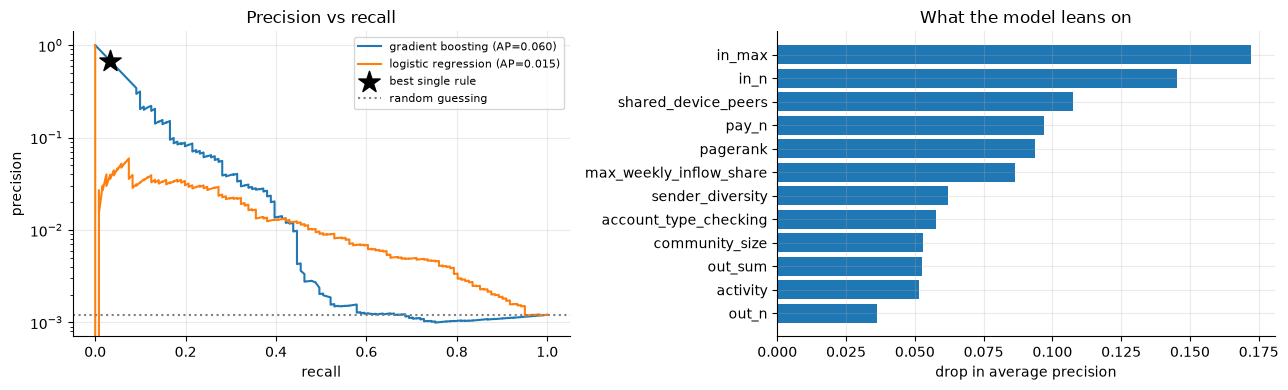

In [21]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, oof in oof_scores.items():
    p, r, _ = precision_recall_curve(y, oof)
    axes[0].plot(r, p, label=f"{name} (AP={average_precision_score(y, oof):.3f})")
# the refined rule, as a single point
best_rule = rule_hits["...and the burst is >80% of lifetime inflow"]
s = score(best_rule, "rule")
axes[0].scatter([s["recall_pct"]/100], [s["precision_pct"]/100], marker="*", s=260,
                color="black", zorder=5, label="best single rule")
axes[0].axhline(base_rate, ls=":", color="grey", label="random guessing")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision"); axes[0].set_yscale("log")
axes[0].set_title("Precision vs recall"); axes[0].legend(fontsize=8)

m = HistGradientBoostingClassifier(max_iter=300, random_state=0).fit(A, y)
from sklearn.inspection import permutation_importance
imp = permutation_importance(m, A, y, n_repeats=3, random_state=0, scoring="average_precision")
order = np.argsort(-imp.importances_mean)[:12][::-1]
axes[1].barh([feature_names[i] for i in order], imp.importances_mean[order], color="tab:blue")
axes[1].set_title("What the model leans on"); axes[1].set_xlabel("drop in average precision")
plt.tight_layout(); plt.show()

The starred point on the left chart is the refined Cypher rule from section 4, and it sits **above** both model curves. At its own operating point, 6 alerts, that one rule is more precise than anything the model offers. The model's advantage is that it keeps producing useful alerts as you widen the queue, where the rule simply stops at six.

The feature ranking on the right is readable, which matters for anyone who has to defend a model to a regulator.

The features that carry weight are value-based and relational rather than simple counts, which is consistent with everything sections 3 and 4 showed. The device-sharing feature is worth pausing on: it is the synthetic-identity signal, and it only works because the generator also creates innocent household device sharing for it to stand out against.

Now the question nobody asks often enough: what is the model missing?

In [22]:
model_scores = oof_scores["gradient boosting"]
queue_500 = set(X.with_columns(pl.Series("s", model_scores))
                 .sort("s", descending=True).head(500)["account"].to_list())
queue_50 = set(X.with_columns(pl.Series("s", model_scores))
                .sort("s", descending=True).head(50)["account"].to_list())

by_typology = query(TRUTH, """
MATCH (a:Account)-[:IN_PATTERN]->(p:Pattern) WHERE p.is_fraud
RETURN p.typology AS typology, collect(DISTINCT a.id) AS accounts
ORDER BY typology
""")
rows = []
all_rules = set().union(*rule_hits.values())
for r in by_typology.iter_rows(named=True):
    accts = set(r["accounts"])
    rows.append({"typology": r["typology"], "accounts": len(accts),
                 "by_rules": len(accts & all_rules),
                 "by_model_500": len(accts & queue_500),
                 "by_either": len(accts & (all_rules | queue_500))})
coverage = pl.DataFrame(rows)
print(coverage)
print("\ntotals:", coverage.select(pl.col(["accounts","by_rules","by_model_500","by_either"]).sum()).to_dicts()[0])
print("\nwhat the top-50 queue is made of:")
print(query(TRUTH, """
UNWIND $ids AS id MATCH (a:Account {id: id})
OPTIONAL MATCH (a)-[:IN_PATTERN]->(p:Pattern)
RETURN CASE WHEN p IS NULL THEN 'not in any pattern (false positive)'
            WHEN p.is_fraud THEN 'fraud: ' + p.typology
            ELSE 'DECOY: ' + p.typology END AS kind, count(*) AS n
ORDER BY n DESC
""", ids=list(queue_50)))

shape: (11, 5)
┌────────────────────┬──────────┬──────────┬──────────────┬───────────┐
│ typology           ┆ accounts ┆ by_rules ┆ by_model_500 ┆ by_either │
│ ---                ┆ ---      ┆ ---      ┆ ---          ┆ ---       │
│ str                ┆ i64      ┆ i64      ┆ i64          ┆ i64       │
╞════════════════════╪══════════╪══════════╪══════════════╪═══════════╡
│ bipartite          ┆ 12       ┆ 0        ┆ 3            ┆ 3         │
│ bust_out           ┆ 2        ┆ 0        ┆ 0            ┆ 0         │
│ cycle              ┆ 9        ┆ 2        ┆ 5            ┆ 5         │
│ fan_in             ┆ 17       ┆ 3        ┆ 1            ┆ 3         │
│ fan_out            ┆ 19       ┆ 2        ┆ 2            ┆ 4         │
│ …                  ┆ …        ┆ …        ┆ …            ┆ …         │
│ mule_network       ┆ 16       ┆ 4        ┆ 9            ┆ 11        │
│ scatter_gather     ┆ 18       ┆ 5        ┆ 5            ┆ 9         │
│ stack              ┆ 7        ┆ 1        ┆ 0   

Two things fall out of this, and together they are the notebook's conclusion.

**The model and the rules fail on different typologies.** The model is strong on mule networks (9 of 16) and synthetic identities (7 of 11), which leave device and chaining signatures, and it finds bipartite schemes the rules miss entirely. It finds **none** of the stack or bust-out accounts, and only 1 of 4 structuring. The rules catch all four structuring accounts, because a rule that looks just under the reporting threshold is exactly the right tool for a scheme defined by staying just under the reporting threshold. Read the `by_either` column: on nearly every row the union beats both. Neither approach subsumes the other.

**The model does not chase decoys.** Of the 60 lookalike-legitimate accounts, the rules between them flag 12 and the model's top 500 flags 1. The top-50 queue contains no decoys at all: its false positives are ordinary accounts, which are far cheaper to dismiss than a customer who genuinely looks like a laundering ring. A model weighing thirty signals is much harder to fool with shape alone than a rule looking at one.

**What this means for the business.** A model is worth building, and it should be scored on precision at your actual review capacity rather than on AUC. But it is not a replacement for rules, because there are whole categories of crime it does not see and that a three-line rule catches easily.

## 7. What to actually do

Pulling the numbers together.

In [23]:
final = []
for name, ids in rule_hits.items():
    final.append(score(ids, f"rule: {name}"))
final.append(score(all_rules, "rule: all of the above combined"))
for k in (50, 500):
    q = set(X.with_columns(pl.Series("s", model_scores)).sort("s", descending=True).head(k)["account"].to_list())
    final.append(score(q, f"model: top {k}"))
final.append(score(all_rules | queue_500, "layered: all rules + model top 500"))
print(pl.DataFrame(final).sort("recall_pct", descending=True))

shape: (10, 6)
┌─────────────────────────────────┬────────┬────────┬───────────────┬────────────┬────────────┐
│ rule                            ┆ alerts ┆ caught ┆ precision_pct ┆ recall_pct ┆ decoys_hit │
│ ---                             ┆ ---    ┆ ---    ┆ ---           ┆ ---        ┆ ---        │
│ str                             ┆ i64    ┆ i64    ┆ f64           ┆ f64        ┆ i64        │
╞═════════════════════════════════╪════════╪════════╪═══════════════╪════════════╪════════════╡
│ layered: all rules + model top… ┆ 3771   ┆ 45     ┆ 1.2           ┆ 37.2       ┆ 12         │
│ model: top 500                  ┆ 500    ┆ 31     ┆ 6.2           ┆ 25.6       ┆ 1          │
│ rule: all of the above combine… ┆ 3332   ┆ 20     ┆ 0.6           ┆ 16.5       ┆ 12         │
│ model: top 50                   ┆ 50     ┆ 12     ┆ 24.0          ┆ 9.9        ┆ 0          │
│ rule: fan-in >= 8 senders, who… ┆ 2473   ┆ 8      ┆ 0.3           ┆ 6.6        ┆ 9          │
│ rule: fan-in >= 5 sende

### The recommendation

**1. Deploy the layered version, not either half.** All rules together find 16.5% of the fraud accounts. The model's top 500 finds 25.6%. Run both and you find 37.2%, because they miss different things. That is the single largest improvement available from anything built in this notebook, and it costs nothing more than running two things instead of one.

**2. Use two operating points, not one threshold.** They serve different purposes:

- **Auto-escalate** the refined burst rule. 6 alerts, 4 of them real, no decoys. At 67% precision this can go almost straight to an investigator with little triage.
- **A ranked review queue** from the model. Set its length by how many analysts you have, not by a probability cut-off. The top 25 runs at 32% precision, the top 50 at 24%, the top 100 at 16%, the top 500 at 6%. Every one of those beats random review by between 50 and 264 times.

**3. Report precision at your review capacity. Do not report AUC.** The logistic regression in section 6 has a ROC AUC of 0.82 against gradient boosting's 0.58, and it puts zero frauds in the top 25 where the other model puts 8. If a vendor or an internal team quotes you an AUC on a problem with a 0.1% base rate, ask for precision at a fixed queue length instead. It is a different question and it is the one that determines whether the system is worth running.

**4. Stop counting distinct senders and start measuring concentration.** Section 3 showed that fraud accounts here have *fewer* senders than the legitimate lookalikes and nearly triple the inflow. Every sender-counting rule we wrote caught decoys; the one rule that asked whether inflow arrived in a single concentrated burst reached 67% precision and caught none. If an existing fan-in rule is generating complaints, this is very likely why.

**5. Keep decoys in every evaluation you ever run.** The weekly fan-in rule would have passed a review that only measured recall, and it flags every legitimate group-payment situation in the dataset. The only reason we know that is that the test data contained innocent customers who look guilty. A real backtest needs the same thing: a set of confirmed-clean customers who tripped the same shapes. Without them, precision numbers are flattering and meaningless.

**6. The biggest lever is more history, not a better model.** At this scale each account averages nine transactions over 90 days. Bursts, cycles and velocity all need repeated behaviour to stand out, and nine points is not enough for any of them. Before tuning hyperparameters, check whether the detection window can be widened. Test that claim directly by regenerating with a longer period and rerunning this notebook:

```
graphfaker fraud --scale 0.01 --seed 42 --period-days 365 --out ./bank-year graphfaker load neo4j ./bank-year --database bank-year --create
```

**7. Do not trust a graph algorithm because it is a graph algorithm.** Weakly connected components had literally zero discriminating power here: every pattern, criminal and innocent, sat inside the one giant component. Amount-weighted PageRank managed 1.5% precision, worse than a one-line rule. Louvain did carry real signal, fraud rings placing 2.58 accounts per community against the decoys' 1.05, and the way to use it was as one feature among thirty rather than as an answer. Measure first, and be willing to throw two of the three away.

### What this notebook does not tell you

Honesty about the limits, because the numbers above are specific and it would be easy to over-read them.

- **One dataset, one seed, one hardness level.** Rerun at `--hardness high` and the rules get worse; at `low` they get much better. Vary the seed and 121 positives means the model's numbers move by several points. The standard deviations in section 6 are the honest error bar, and on average precision they are most of the value.
- **121 positives is very few.** Any model fitted on this is unstable, and the feature importances should be read as directional rather than precise.
- **These typologies are the ones GraphFaker injects.** A real bank sees others, and real launderers adapt once they learn what you detect. Nothing here models an adversary responding to your controls.
- **Nothing here is a cost model.** The right queue length depends on what an investigation costs and what a missed case costs, and neither is in this dataset.

In [24]:
driver.close()
print("done")

done
